## Lab - EDA Univariate Analysis: Diving into Amazon UK Product Insights

**Objective**: Explore the product listing dynamics on Amazon UK to extract actionable business insights. By understanding the distribution, central tendencies, and relationships of various product attributes, businesses can make more informed decisions on product positioning, pricing strategies, and inventory management.

**Dataset**: This lab utilizes the [Amazon UK product dataset](https://www.kaggle.com/datasets/asaniczka/uk-optimal-product-price-prediction/)
which provides information on product categories, brands, prices, ratings, and more from from Amazon UK. You'll need to download it to start working with it.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('amz_uk_price_prediction_dataset.csv')

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2443651 entries, 0 to 2443650
Data columns (total 9 columns):
 #   Column             Dtype  
---  ------             -----  
 0   uid                int64  
 1   asin               str    
 2   title              str    
 3   stars              float64
 4   reviews            int64  
 5   price              float64
 6   isBestSeller       bool   
 7   boughtInLastMonth  int64  
 8   category           str    
dtypes: bool(1), float64(2), int64(3), str(3)
memory usage: 495.8 MB


In [4]:
df.sample(10)

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
2278250,2630566,B0C4NMNVZH,HOOCI 350W Subwoofer Amplifier Board For Sanke...,0.0,0,38.84,False,0,Hi-Fi Receivers & Separates
117604,126634,B076DH2859,Modern House Numbers - Yellow with Black Acryl...,4.7,15,18.50,False,0,Handmade Gifts
1677408,1890366,B083SCPFQK,"Pixel G1s RGB Video Light, Built-in 12W Rechar...",4.7,3709,74.99,False,0,Camera & Photo Accessories
2329452,2685120,B07PRK5CSK,7W GU10 SMD LED Spotlight Lamp Downlight A+ Ra...,3.9,47,9.99,False,0,Light Bulbs
1052214,1161926,B09YNCMHJZ,E27 Bulb Camera with Speaker Pan Tilt Security...,3.8,39,19.99,False,0,Surveillance Cameras
185007,198340,B07W63PFF9,"Gunolye Bamboo Bookshelf,Tree Shape Floorstand...",4.3,207,26.99,False,0,Furniture & Lighting
1222204,1349417,B0BF4BHQFC,Dacvgog Scooter for Electric Electric,0.0,0,3.66,False,0,Sports & Outdoors
78090,84719,B08XK52QZ5,Baby Sunglasses Classic Retro Solid Color Roun...,4.1,140,6.99,False,0,Boys
97270,105434,B0823YSQF4,Gravity MS CAB CL 01 S Cab Clamp Microphone Ho...,4.3,62,35.48,False,0,Microphones
1131204,1251717,B001O53NCW,"Scan SCAPPEGDV Directly Vented Safety Goggles,...",4.4,207,4.58,False,100,Safety & Security


In [5]:
df.isna().sum()

uid                  0
asin                 0
title                0
stars                0
reviews              0
price                0
isBestSeller         0
boughtInLastMonth    0
category             0
dtype: int64

### Part 1: Understanding Product Categories

**Business Question**: What are the most popular product categories on Amazon UK, and how do they compare in terms of listing frequency?

1. **Frequency Tables**:
    - Generate a frequency table for the product `category`.
    - Which are the top 5 most listed product categories?

In [ ]:
cat_freq = pd.DataFrame(df['category'].value_counts())
display(cat_freq)

,count
category,
Sports & Outdoors,836265
Beauty,19312
"Handmade Clothing, Shoes & Accessories",19229
Bath & Body,19092
Birthday Gifts,18978
...,...
Motorbike Chassis,107
Alexa Built-In Devices,107
Plugs,107


In [17]:
top_5_cats = ", ".join(cat_freq[:5].index[:-1]) + " and " + cat_freq[:5].index[-1]
print(f" The 5 most listed product categories are {top_5_cats}.")

 The 5 most listed product categories are Sports & Outdoors, Beauty, Handmade Clothing, Shoes & Accessories, Bath & Body and Birthday Gifts.


In [116]:
cat_freq[:5].sum()/ cat_freq.sum()

count    0.373571
dtype: float64

2. **Visualizations**:
    - Display the distribution of products across different categories using a bar chart. *If you face problems understanding the chart, do it for a subset of top categories.*
    - For a subset of top categories, visualize their proportions using a pie chart. Does any category dominate the listings?

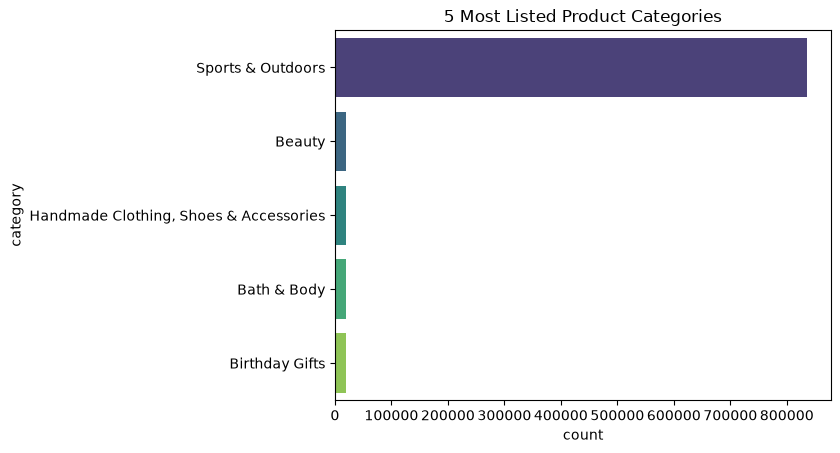

In [112]:
# plt.figure(figsize=(10, 12))

sns.barplot(
    data=cat_freq[:5],
    x="count",
    y="category",
    palette='viridis',
    hue="category",
    # legend=True,
    
)

# plt.tight_layout()
plt.title('5 Most Listed Product Categories')
plt.show()

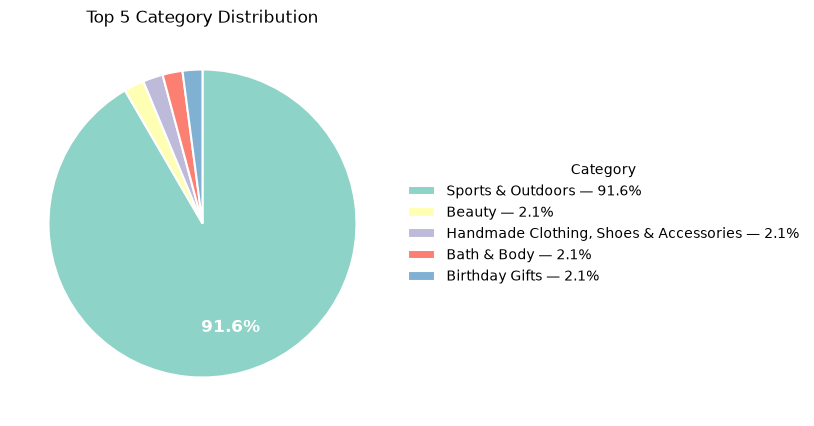

In [114]:
cat_proportions = df['category'].value_counts(normalize=True)[:5]

norm_cat_proportions = cat_proportions / cat_proportions.sum()

fig, ax = plt.subplots(figsize=(7, 5))

counts = cat_freq.iloc[:5, 0].to_numpy()

wedges, _, _ = ax.pie(
    counts,
    startangle=90,
    counterclock=False,
    colors=sns.color_palette('Set3', n_colors=len(counts)),
    autopct=lambda p: f'{p:.1f}%' if p >= 5 else '',  # skip the slices too thin to hold text
    pctdistance=0.7,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
    textprops={'color': 'white', 'fontsize': 12, 'fontweight': 'bold'},
)

ax.legend(
    wedges,
    [f'{label} — {p:.1%}' for label, p in norm_cat_proportions.items()],
    title='Category',
    loc='center left',
    bbox_to_anchor=(1, 0.5),
    frameon=False,
)

ax.set_title('Top 5 Category Distribution')
plt.show()


### Part 2: Delving into Product Pricing

**Business Question**: How are products priced on Amazon UK, and are there specific price points or ranges that are more common?

1. **Measures of Centrality**:
    - Calculate the mean, median, and mode for the `price` of products.
    - What's the average price point of products listed? How does this compare with the most common price point (mode)?

In [105]:
print(f"The mean product price is £{round(df['price'].mean(),2)}.")
print(f"The median of product prices is £{round(df['price'].median(),2)}.")
print(f"The mode of product prices is £{df['price'].mode().iloc[0]}.")

The mean product price is £89.24.
The median of product prices is £19.09.
The mode of product prices is £9.99.


2. **Measures of Dispersion**:
    - Determine the variance, standard deviation, range, and interquartile range for product `price`.
    - How varied are the product prices? Are there any indicators of a significant spread in prices?

In [106]:
print(f"The variance of product prices is {round(df['price'].var(),2)} pounds².")
print(f"The standard deviation of product prices is £{round(df['price'].std(),2)}.")
print(f"The range of product prices is £{round(df['price'].max() - df['price'].min(),2)}.")
print(f"The interquartile range of product prices is £{round(df['price'].quantile(0.75) - df['price'].quantile(0.25),2)}.")

The variance of product prices is 119445.49 pounds².
The standard deviation of product prices is £345.61.
The range of product prices is £100000.0.
The interquartile range of product prices is £36.0.


3. **Visualizations**:
    - Is there a specific price range where most products fall? Plot a histogram to visualize the distribution of product prices. *If its hard to read these diagrams, think why this is, and explain how it could be solved.*.
    - Are there products that are priced significantly higher than the rest? Use a box plot to showcase the spread and potential outliers in product pricing. 

It is hard to read the histogram because the price range is much larger than the window where most of the prices are located. One way to solve this is to plot the price, x-axis, in log scale. Another solution is to select a smaller range to better visualize, such as the interquartile range.

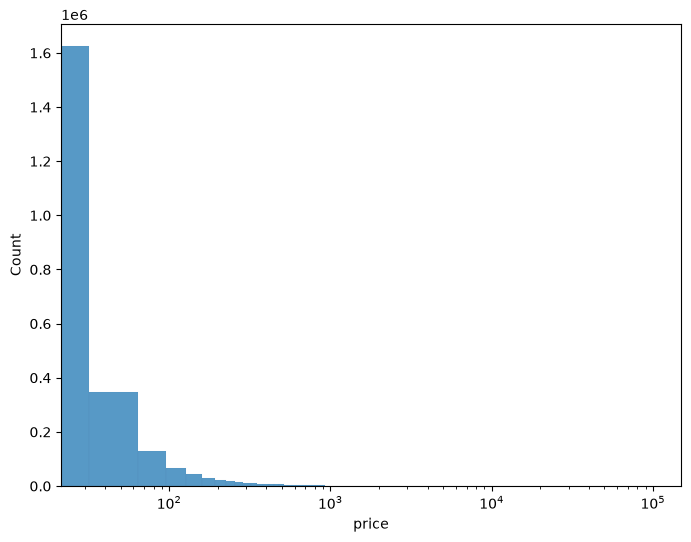

In [ ]:
# Log scale plot
fig, ax = plt.subplots(figsize=(8, 6))

sns.histplot(df['price'], bins="auto")
ax.set_xscale("log")
plt.show()

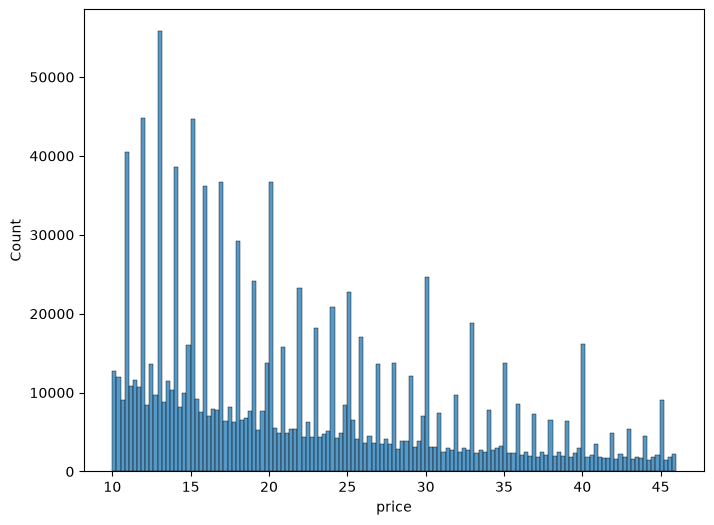

In [148]:
# Interquartile range plot
quartile_1 = df['price'].quantile(0.25)
quartile_3 = df['price'].quantile(0.75)
iqr_condition = (df['price'] > quartile_1) & (df['price'] < quartile_3 )

fig, ax = plt.subplots(figsize=(8, 6))

sns.histplot(df['price'][iqr_condition], bins="auto")
plt.show()


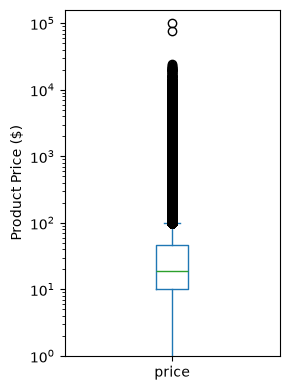

In [ ]:
ax = (df['price']).plot.box(figsize=(3, 4))
ax.set_ylabel("Product Price (£)")
ax.set_yscale("log")
ax.set_ylim(bottom=10e-1)

plt.tight_layout()
plt.show()

In [144]:
# Percentage of outliers
iqr = quartile_3 - quartile_1
outlier_condition = (df['price'] < quartile_1 - 1.5*iqr) | (df['price'] > quartile_3 + 1.5*iqr)
print(round(df['price'][outlier_condition].count()*100/ df['price'].count(),2),"%")

13.41 %


### Part 3: Unpacking Product Ratings

**Business Question**: How do customers rate products on Amazon UK, and are there any patterns or tendencies in the ratings?

1. **Measures of Centrality**:
    - Calculate the mean, median, and mode for the rating of products.
    - How do customers generally rate products? Is there a common trend?

In [131]:
print(f"The mean product rating is {round(df['stars'].mean(),2)}.")
print(f"The median of product ratings is {round(df['stars'].median(),2)}.")
print(f"The mode of product ratings is {df['stars'].mode().iloc[0]}.")

The mean product rating is 2.15.
The median of product ratings is 0.0.
The mode of product ratings is 0.0.


2. **Measures of Dispersion**:
    - Determine the variance, standard deviation, and interquartile range for product `rating`.
    - Are the ratings consistent, or is there a wide variation in customer feedback?

In [132]:
print(f"The variance of product ratings is {round(df['stars'].var(),2)}.")
print(f"The standard deviation of product ratings is {round(df['stars'].std(),2)}.")
print(f"The interquartile range of product ratings is {round(df['stars'].quantile(0.75) - df['stars'].quantile(0.25),2)}.")

The variance of product ratings is 4.82.
The standard deviation of product ratings is 2.19.
The interquartile range of product ratings is 4.4.


3. **Shape of the Distribution**:
    - Calculate the skewness and kurtosis for the `rating` column. 
    - Are the ratings normally distributed, or do they lean towards higher or lower values?

In [134]:
print(f"The skewness of product ratings is {round(df['stars'].skew(),2)}.")
print(f"The kurtosis of product ratings is {round(df['stars'].kurtosis(),2)}.")

The skewness of product ratings is 0.08.
The kurtosis of product ratings is -1.93.


4. **Visualizations**:
    - Plot a histogram to visualize the distribution of product ratings. Is there a specific rating that is more common?

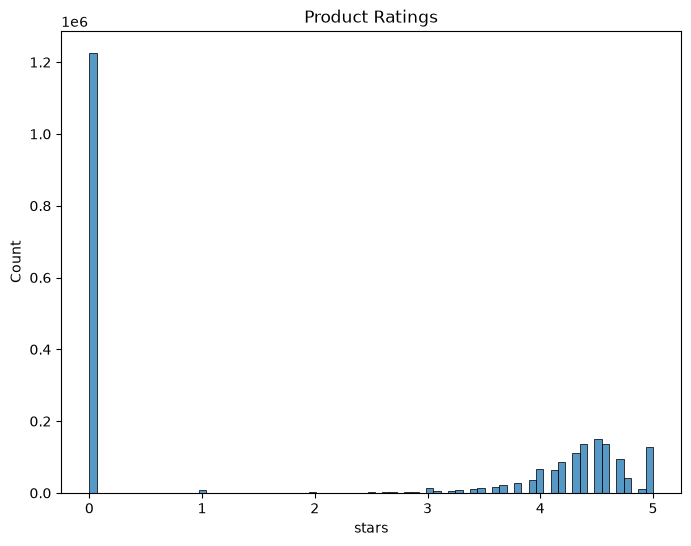

In [143]:
fig, ax = plt.subplots(figsize=(8, 6))

# sns.histplot(df['stars'][df['stars'] > 0], bins="auto")
sns.histplot(df['stars'], bins="auto")
plt.title('Product Ratings')
plt.show()

# Business Report

### Part 1: Understanding Product Categories

**Business Question**: What are the most popular product categories on Amazon UK, and how do they compare in terms of listing frequency?

- The 5 most listed product categories are Sports & Outdoors, Beauty, Handmade Clothing, Shoes & Accessories, Bath & Body and Birthday Gifts. 
- These categories represent 37% of the total listed products.
- Among the top 5 most listed product categories, Sports & Outdoors corresponds to 91.6% of them, whereas the each of the remaining represent 2.1%.


### Part 2: Delving into Product Pricing

**Business Question**: How are products priced on Amazon UK, and are there specific price points or ranges that are more common?

- The average price point of listed products is £89.24 deviates considerably from the most common price point of £9.99, which means that there are a large number of products that surpass the latter.
- A large range of product prices of £100,000.0 already indicates a substantial spread in prices. Moreover, a significant standard deviation of £345.61 quantifies how spread out the prices are from the mean.
- An interquartile range of £36.0 demonstrates that 50% of the products are within that window around the median price of £19.09.
- From the box plot, one can observe a significant number of outliers, meaning products whose prices are greater than the third quartile + 1.5 times the interquartile range. This corresponds to 13.41% of products.

### Part 3: Unpacking Product Ratings

**Business Question**: How do customers rate products on Amazon UK, and are there any patterns or tendencies in the ratings?

- It becomes clear that most customers rate products with zero stars since the mode of ratings 0.0. In addition, at least 50% of the ratings are zero stars, given the median rating of 0.0. However with a mean rating of 2.15, one can infer a significant number of ratings above the average. 
- The large standard deviation of 2.19 denotes a substantial spread of ratings. Also, an interquartile range of product ratings of 4.4 quantifies that 75% of the ratings are found within 0.0 and 4.4, demonstrating large variability within the \[0,5\] range.
- A small positive skewness of 0.08 indicates that the rating distribution is positively skewed, meaning a longer tail on the right side, whereas the bulk of the data is concentrated on the left. Furthermore, a substantial negative value of -1.93 for the kurtosis denotes few extreme outliers and ratings more evenly spread than a normal distribution.
